In [ ]:
# ! pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.3 MB/s eta 0:00:00


# Prepare Environment

In [1]:
# Check for local CSV; if missing, download from Firebase using pyasebase/pyrebase
import os
import pandas as pd
from pybaseball import pitching_stats
import numpy as np

csv_path = "./data/pitching_stats.csv"

if os.path.exists(csv_path):
    print(f"Found {csv_path}, reading into DataFrame.")
    data = pd.read_csv(csv_path)
else:
    print(f"{csv_path} not found — attempting to download using pybaseball.")
    qual = 10
    start_season = 2015
    end_season = 2025
    data = pitching_stats(start_season=start_season, end_season=end_season, qual=qual)
    # data.to_csv('./data/pitching_stats.csv', index=False)

Found ./data/pitching_stats.csv, reading into DataFrame.


# Prepare Training Data

In [3]:
# Process data for 3D tensor - organized by player-season combination
import torch
import numpy as np
import pandas as pd

# Select relevant columns
features = [
    'Age',
    'ERA',
    'G',
    'GS',
    'IP',
    'TBF',
    'HR',
    'BB',
    'IBB',
    'HBP',
    'SO',
    'GB',
    'GB%',
    'FB',
    'FB%',
    'LD',
    'LD%',
    'IFFB',
    'Pitches',
    'BABIP',
    'WHIP',
    'FIP',
    'xFIP',
    'SIERA',
    'CStr%',
    'CSW%',
    'Barrels',
    'Barrel%',
    'HardHit',
    'HardHit%',
]

target = 'WAR'

# Qualification parameter: minimum IP in target season to include in training set
min_qual_ip = 50  # Set to > 0 to filter by innings pitched (e.g., 50 for minimum 50 IP)

# Ensure data has the necessary columns
required_cols = features + [target, 'IDfg', 'Season']
data_processed = data.reindex(columns=[c for c in data.columns if c in required_cols]).fillna(0)

# Group by player
grouped = data_processed.groupby('IDfg')

sequences = []
targets = []
metadata = []  # Track player_id, season for each row

nlookback = 5

for player_id, player_data in grouped:
    # Sort by season
    player_data = player_data.sort_values('Season').reset_index(drop=True)

    # Need at least 2 years: nlookback periods + 1 for target
    if len(player_data) >= 2:
        for i in range(len(player_data) - 1):
            # Check qualification: target season must have at least min_qual_ip innings pitched
            target_ip = player_data.iloc[i + 1]['IP']
            if target_ip < min_qual_ip:
                continue  # Skip this record if it doesn't meet qualification
            
            # lookback, padded with 0s if less
            seq_length = min(nlookback, i + 1)
            seq_data = np.zeros((nlookback, len(features)))

            # Select the rows for this sequence
            seq_rows = player_data.iloc[i - seq_length + 1:i + 1]

            # Reindex columns to `features` to ensure consistent order
            vals = seq_rows.reindex(columns=features).fillna(0).values
            if vals.ndim == 1:
                vals = vals.reshape(1, -1)

            # Safety: if column count mismatches, trim or pad
            if vals.shape[1] != len(features):
                if vals.shape[1] > len(features):
                    vals = vals[:, :len(features)]
                else:
                    pad = np.zeros((vals.shape[0], len(features) - vals.shape[1]))
                    vals = np.hstack([vals, pad])

            # Place at the end of seq_data (right-align)
            seq_data[nlookback - seq_length:] = vals

            # Target: WAR of next year
            target_season = player_data.iloc[i + 1]['Season']
            target_war = player_data.iloc[i + 1][target]

            sequences.append(seq_data)
            targets.append(target_war)
            metadata.append({
                'player_id': player_id,
                'current_season': int(player_data.iloc[i]['Season']),
                'target_season': int(target_season),
                'target_ip': float(target_ip),
            })

# Convert to numpy arrays and torch tensors
sequences = np.array(sequences)  # Shape: (num_sequences, nlookback, len(features))
targets = np.array(targets)      # Shape: (num_sequences,)

X = torch.tensor(sequences, dtype=torch.float32)
y = torch.tensor(targets, dtype=torch.float32)

# Create metadata DataFrame indexed by player_id and target_season
metadata_df = pd.DataFrame(metadata)
metadata_df = metadata_df.set_index(['player_id', 'target_season'])

print(f"Tensor shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Metadata rows: {len(metadata_df)}")
print(f"Qualification filter: min_qual_ip = {min_qual_ip}")
print(f"\nFirst few metadata entries:")
print(metadata_df.head())
print(f"\nSample sequence for entry 0:\n{X[0]}")
print(f"Corresponding target: {y[0]}")


Tensor shape: torch.Size([2804, 5, 30])
Target shape: torch.Size([2804])
Metadata rows: 2804
Qualification filter: min_qual_ip = 50

First few metadata entries:
                         current_season  target_ip
player_id target_season                           
18        2016                     2015       53.2
375       2016                     2015      191.2
          2017                     2016      143.0
          2018                     2017      146.1
404       2016                     2015      179.2

Sample sequence for entry 0:
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0

# Prepare Prediction Data

In [4]:
# Create prediction set for 2025 season
pred_season = 2025

pred_sequences = []
pred_metadata = []

for player_id, player_data in grouped:
    # Sort by season
    player_data = player_data.sort_values('Season').reset_index(drop=True)
    
    # Check if player has data for pred_season
    if pred_season in player_data['Season'].values:
        # Find the index of pred_season
        pred_idx = player_data[player_data['Season'] == pred_season].index[0]
        
        # Build sequence using data up to pred_season
        seq_length = min(nlookback, pred_idx + 1)
        seq_data = np.zeros((nlookback, len(features)))
        
        # Select rows from pred_season going back nlookback periods
        seq_rows = player_data.iloc[pred_idx - seq_length + 1:pred_idx + 1]
        
        # Reindex to ensure consistent column order
        vals = seq_rows.reindex(columns=features).fillna(0).values
        if vals.ndim == 1:
            vals = vals.reshape(1, -1)
        
        # Handle column mismatches
        if vals.shape[1] != len(features):
            if vals.shape[1] > len(features):
                vals = vals[:, :len(features)]
            else:
                pad = np.zeros((vals.shape[0], len(features) - vals.shape[1]))
                vals = np.hstack([vals, pad])
        
        # Place at end of seq_data (right-align)
        seq_data[nlookback - seq_length:] = vals
        
        pred_sequences.append(seq_data)
        pred_metadata.append({
            'player_id': player_id,
            'prediction_season': pred_season,
        })

# Convert to torch tensors
X_pred = torch.tensor(np.array(pred_sequences), dtype=torch.float32)
pred_metadata_df = pd.DataFrame(pred_metadata).set_index('player_id')

print(f"Prediction set size: {X_pred.shape}")
print(f"Number of players with {pred_season} data: {len(pred_metadata_df)}")
print(f"\nFirst few prediction metadata entries:")
print(pred_metadata_df.head())


Prediction set size: torch.Size([657, 5, 30])
Number of players with 2025 data: 657

First few prediction metadata entries:
           prediction_season
player_id                   
2036                    2025
3096                    2025
3137                    2025
3237                    2025
3548                    2025


# Define Model using 1D-CNN

In [5]:
# 1D-CNN Model for WAR Prediction
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

class PitchingCNN(nn.Module):
    def __init__(self, input_channels=6, seq_length=3, num_classes=1):
        super(PitchingCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=2, stride=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool = nn.AdaptiveAvgPool1d(1)  # Use adaptive pooling to ensure output size
        self.dropout = nn.Dropout(0.4)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=1, stride=1)  # kernel=1 to avoid size issues
        self.bn2 = nn.BatchNorm1d(64)
        self.pool = nn.AdaptiveAvgPool1d(1)  # Use adaptive pooling to ensure output size
        self.dropout = nn.Dropout(0.4)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Input: (batch, seq_length=3, features=6)
        # Permute to (batch, features=6, seq_length=3) for Conv1d
        x = x.permute(0, 2, 1)

        x = torch.relu(self.conv1(x))  # (batch, 32, 2)
        x = self.pool(x)  # (batch, 32, 1)
        x = self.bn1(x)
        x = self.dropout(x)
   
        
        x = torch.relu(self.conv2(x))  # (batch, 64, 2)
        x = self.pool(x)  # (batch, 64, 1)
        x = self.bn2(x)
        x = self.dropout(x)
        
        x = self.flatten(x)  # (batch, 64)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.bn3(x)
        x = self.fc2(x)
        return x

def prepare_data(X, y, test_size=0.2, batch_size=32):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Normalize features
    scaler = StandardScaler()
    X_train_reshaped = X_train.view(X_train.shape[0], -1).numpy()
    X_test_reshaped = X_test.view(X_test.shape[0], -1).numpy()

    X_train_scaled = scaler.fit_transform(X_train_reshaped)
    X_test_scaled = scaler.transform(X_test_reshaped)

    X_train = torch.tensor(X_train_scaled.reshape(X_train.shape), dtype=torch.float32)
    X_test = torch.tensor(X_test_scaled.reshape(X_test.shape), dtype=torch.float32)

    # Create datasets
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, scaler

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def train_model(model, train_loader, test_loader, num_epochs=100, learning_rate=0.001, device='cpu', patience=15, early_stopping_enabled=True):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    early_stopping = EarlyStopping(patience=patience) if early_stopping_enabled else None

    train_losses = []
    test_losses = []
    best_model_state = None
    best_test_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), targets)
                test_loss += loss.item() * inputs.size(0)

        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

        # Track best model
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_model_state = model.state_dict().copy()

        # Early stopping check
        if early_stopping_enabled:
            early_stopping(test_loss)
            if early_stopping.early_stop:
                print(f'Early stopping at epoch {epoch+1}. Best Test Loss: {best_test_loss:.4f}')
                break

    # Load best model if early stopping was used
    if best_model_state is not None and early_stopping_enabled:
        model.load_state_dict(best_model_state)

    return train_losses, test_losses

def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

# Example usage:
# model = PitchingCNN(input_channels=6, seq_length=3)
# train_loader, test_loader, scaler = prepare_data(X, y)
# train_losses, test_losses = train_model(model, train_loader, test_loader, device='cpu')
# plot_losses(train_losses, test_losses)

# Train Model

In [6]:
model = PitchingCNN(input_channels=len(features), seq_length=3)
print(model)

PitchingCNN(
  (conv1): Conv1d(30, 32, kernel_size=(2,), stride=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool1d(output_size=1)
  (dropout): Dropout(p=0.4, inplace=False)
  (conv2): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


Using device: mps
Epoch 10/100, Train Loss: 2.0780, Test Loss: 1.8900
Epoch 20/100, Train Loss: 1.5757, Test Loss: 1.3455
Epoch 30/100, Train Loss: 1.4437, Test Loss: 1.3250
Epoch 40/100, Train Loss: 1.3693, Test Loss: 1.3155
Epoch 50/100, Train Loss: 1.3150, Test Loss: 1.2941
Epoch 60/100, Train Loss: 1.3055, Test Loss: 1.2951
Epoch 70/100, Train Loss: 1.3254, Test Loss: 1.2778
Epoch 80/100, Train Loss: 1.2505, Test Loss: 1.3034
Epoch 90/100, Train Loss: 1.2328, Test Loss: 1.2822
Early stopping at epoch 98. Best Test Loss: 1.2672


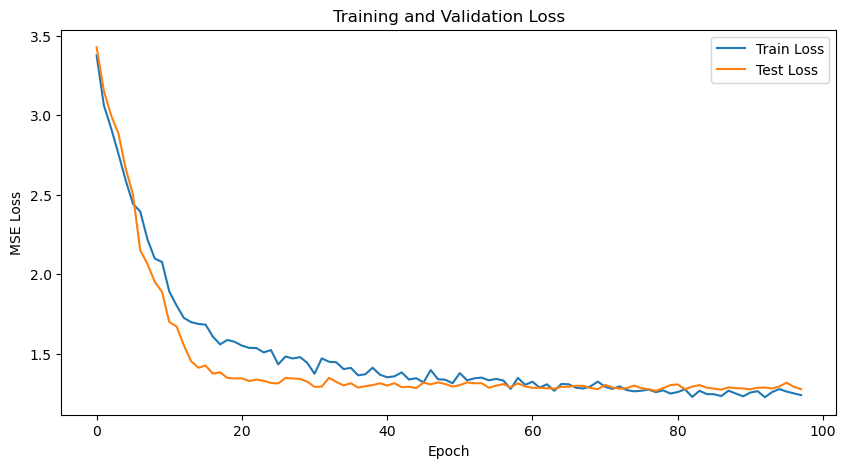

Test MSE: 1.2777
Test R²: 0.3976


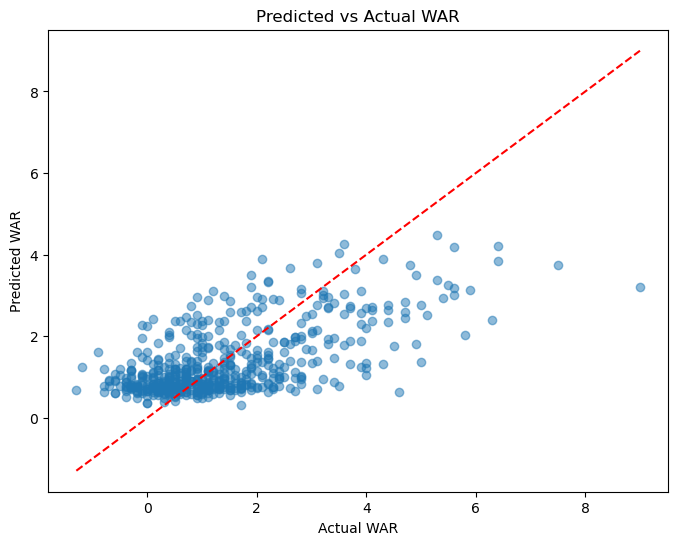

Scaler and model saved for predictions


In [7]:
# Train the 1D-CNN model
# Check if MPS is available
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = PitchingCNN(input_channels=len(features), seq_length=nlookback)

# Prepare data and save scaler
train_loader, test_loader, scaler = prepare_data(X, y, batch_size=256)

# Train model
train_losses, test_losses = train_model(model, train_loader, test_loader, learning_rate=1e-3, num_epochs=100, device=device, patience=20, early_stopping_enabled=True)

# Plot losses
plot_losses(train_losses, test_losses)

# Make predictions on test set
model.eval()
predictions = []
actuals = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predictions.extend(outputs.cpu().numpy().flatten())
        actuals.extend(targets.numpy())

# Calculate metrics
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(actuals, predictions)
r2 = r2_score(actuals, predictions)
print(f"Test MSE: {mse:.4f}")
print(f"Test R²: {r2:.4f}")

# Plot predictions vs actuals
plt.figure(figsize=(8, 6))
plt.scatter(actuals, predictions, alpha=0.5)
plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--')
plt.xlabel('Actual WAR')
plt.ylabel('Predicted WAR')
plt.title('Predicted vs Actual WAR')
plt.show()

# Store scaler and model for later use
print("Scaler and model saved for predictions")

# Generate Predictions for 2026

In [12]:
# Store predictions using saved scaler

# Scale prediction data using the fitted scaler
X_pred_reshaped = X_pred.view(X_pred.shape[0], -1).numpy()
X_pred_scaled = scaler.transform(X_pred_reshaped)
X_pred_tensor = torch.tensor(X_pred_scaled.reshape(X_pred.shape), dtype=torch.float32)

# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(X_pred_tensor.to(device))

# Convert to numpy
pred_war = predictions.cpu().numpy().flatten()

# Add to results
results_df = pred_metadata_df.copy()
results_df['predicted_war_2026'] = pred_war

print("Predictions (now in correct WAR scale):")
print(results_df.head())
print(f"\nPredicted WAR range: [{pred_war.min():.2f}, {pred_war.max():.2f}]")

# Save predictions to CSV
results_df.to_csv('./results/cnn/2026_war_predictions.csv', index=True)
print(f"\nPredictions saved to ./results/cnn/2026_war_predictions.csv")

Predictions (now in correct WAR scale):
           prediction_season  predicted_war_2026
player_id                                       
2036                    2025            1.001129
3096                    2025            0.441738
3137                    2025            0.764711
3237                    2025            0.373122
3548                    2025            0.905061

Predicted WAR range: [0.22, 4.04]

Predictions saved to ./results/cnn/2026_war_predictions.csv


In [13]:
pd.set_option('display.max_rows', 100)
csv_path = "./results/cnn/2026_war_predictions.csv"
if os.path.exists(csv_path):
    print(f"Found {csv_path}, reading into DataFrame.")
    results_df = pd.read_csv(csv_path)

data_2025 = data[data['Season'] == 2025]
results_with_name = results_df.merge(data_2025[['IDfg','Name',]], left_on=['player_id'], right_on=['IDfg'], how='left')

Found ./results/cnn/2026_war_predictions.csv, reading into DataFrame.


In [14]:
results_with_name.sort_values('predicted_war_2026', ascending=False).head(100)[['Name', 'IDfg', 'predicted_war_2026',]]

,Name,IDfg,predicted_war_2026
365,Tarik Skubal,22267,4.040413
640,Paul Skenes,33677,4.035244
456,Hunter Brown,25880,3.706665
494,Garrett Crochet,27463,3.601259
305,Cristopher Sanchez,20778,3.577856
643,Yoshinobu Yamamoto,33825,3.366640
593,Bryan Woo,30279,3.248382
199,Logan Webb,17995,3.214084
270,Jesus Luzardo,19959,3.045746
33,Chris Sale,10603,2.935181


---